In [12]:
# Install required packages
!pip install gensim -q

print("✅ Gensim installed successfully!")

✅ Gensim installed successfully!


In [13]:
"""
GenAI & Machine Learning Bootcamp 2025
Deep Learning & NLP - Intro to NLP: preprocessing
Exercises XP
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# NLP libraries
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, ne_chunk
from nltk.tree import Tree
from gensim.models import Word2Vec
from sklearn.decomposition import PCA

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [14]:
# Download required NLTK data
print("Downloading NLTK data...")

# List of all required NLTK resources
nltk_resources = [
    'punkt',
    'punkt_tab',
    'stopwords',
    'wordnet',
    'omw-1.4',
    'averaged_perceptron_tagger',
    'averaged_perceptron_tagger_eng',
    'maxent_ne_chunker',
    'maxent_ne_chunker_tab',
    'words',
    'tagsets'
]

# Download each resource
for resource in nltk_resources:
    try:
        nltk.download(resource, quiet=False)
    except Exception as e:
        print(f"Warning: Could not download {resource}: {e}")

print("✅ NLTK data downloaded successfully!")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]

✅ NLTK data downloaded successfully!


[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package tagsets to /root/nltk_data...
[nltk_data]   Package tagsets is already up-to-date!


In [15]:
# Sample dataset
data = {
    'Review': [
        'At McDonald\'s the food was ok and the service was bad.',
        'I would not recommend this Japanese restaurant to anyone.',
        'I loved this restaurant when I traveled to Thailand last summer.',
        'The menu of Loving has a wide variety of options.',
        'The staff was friendly and helpful at Google\'s employees restaurant.',
        'The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.',
        'I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.',
        'The sushi at Sushi Express is always fresh and flavorful.',
        'The steakhouse on Main Street has a cozy atmosphere and excellent steaks.',
        'The dessert selection at Sweet Treats is to die for!'
    ]
}

# Create DataFrame
df_raw = pd.DataFrame(data)
print("=" * 80)
print("RAW DATASET")
print("=" * 80)
print(df_raw)

RAW DATASET
                                              Review
0  At McDonald's the food was ok and the service ...
1  I would not recommend this Japanese restaurant...
2  I loved this restaurant when I traveled to Tha...
3  The menu of Loving has a wide variety of options.
4  The staff was friendly and helpful at Google's...
5  The ambiance at Bella Italia is amazing, and t...
6  I had a terrible experience at Pizza Hut. The ...
7  The sushi at Sushi Express is always fresh and...
8  The steakhouse on Main Street has a cozy atmos...
9  The dessert selection at Sweet Treats is to di...


In [16]:
# ============================================================================
# EXERCISE 1: Text Preprocessing Function
# ============================================================================

def preprocess_text(text):
    """
    Preprocess text by:
    1. Converting to lowercase and tokenizing
    2. Removing punctuation
    3. Removing stopwords
    4. Applying lemmatization

    Args:
        text (str): Input text to preprocess

    Returns:
        str: Preprocessed text as a string
    """
    # Step 1: Convert to lowercase and tokenize
    tokens = word_tokenize(text.lower())

    # Step 2: Remove punctuation (keep only alphabetic tokens)
    tokens = [token for token in tokens if token.isalpha()]

    # Step 3: Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words]

    # Step 4: Apply lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]

    # Return as string
    return ' '.join(tokens)

print("✅ Preprocessing function created!")

✅ Preprocessing function created!


In [17]:
# Test preprocessing function
print("=" * 80)
print("TESTING PREPROCESSING FUNCTION")
print("=" * 80)
test_text = df_raw['Review'][0]
print(f"Original: {test_text}")
print(f"Preprocessed: {preprocess_text(test_text)}")

TESTING PREPROCESSING FUNCTION
Original: At McDonald's the food was ok and the service was bad.
Preprocessed: mcdonald food ok service bad


In [18]:
# Apply preprocessing to all reviews
df_raw['Preprocessed_Review'] = df_raw['Review'].apply(preprocess_text)

print("=" * 80)
print("DATASET WITH PREPROCESSED TEXT")
print("=" * 80)
print(df_raw[['Review', 'Preprocessed_Review']])

DATASET WITH PREPROCESSED TEXT
                                              Review  \
0  At McDonald's the food was ok and the service ...   
1  I would not recommend this Japanese restaurant...   
2  I loved this restaurant when I traveled to Tha...   
3  The menu of Loving has a wide variety of options.   
4  The staff was friendly and helpful at Google's...   
5  The ambiance at Bella Italia is amazing, and t...   
6  I had a terrible experience at Pizza Hut. The ...   
7  The sushi at Sushi Express is always fresh and...   
8  The steakhouse on Main Street has a cozy atmos...   
9  The dessert selection at Sweet Treats is to di...   

                                 Preprocessed_Review  
0                       mcdonald food ok service bad  
1         would recommend japanese restaurant anyone  
2     loved restaurant traveled thailand last summer  
3                    menu loving wide variety option  
4  staff friendly helpful google employee restaurant  
5  ambiance bella ital

In [19]:
# Create a new dataset with cleaned text
df_preprocessed = df_raw[['Preprocessed_Review']].copy()
df_preprocessed.columns = ['Review']

print("=" * 80)
print("PREPROCESSED DATASET (SEPARATE)")
print("=" * 80)
print(df_preprocessed)

PREPROCESSED DATASET (SEPARATE)
                                              Review
0                       mcdonald food ok service bad
1         would recommend japanese restaurant anyone
2     loved restaurant traveled thailand last summer
3                    menu loving wide variety option
4  staff friendly helpful google employee restaurant
5  ambiance bella italia amazing pasta dish delic...
6  terrible experience pizza hut pizza burnt serv...
7         sushi sushi express always fresh flavorful
8  steakhouse main street cozy atmosphere excelle...
9                  dessert selection sweet treat die


In [20]:
# ============================================================================
# Named Entity Recognition (NER) Function
# ============================================================================

def perform_ner(text):
    """
    Perform Named Entity Recognition on text using NLTK

    Note: Using NLTK's ne_chunk for NER.
    Can identify entities like PERSON, ORGANIZATION, GPE (Geo-Political Entity), etc.

    Args:
        text (str): Input text for NER

    Returns:
        list: List of tuples containing (entity_text, entity_label)
    """
    # Tokenize and POS tag
    tokens = word_tokenize(text)
    pos_tags = pos_tag(tokens)

    # Perform NER chunking
    chunked = ne_chunk(pos_tags, binary=False)

    # Extract named entities
    entities = []
    for chunk in chunked:
        if isinstance(chunk, Tree):
            entity_text = ' '.join([token for token, pos in chunk.leaves()])
            entity_label = chunk.label()
            entities.append((entity_text, entity_label))

    return entities

print("✅ NER function created!")

✅ NER function created!


In [21]:
# Test NER function on raw data
print("=" * 80)
print("TESTING NER FUNCTION ON RAW DATA")
print("=" * 80)
print("Entity types: PERSON, ORGANIZATION, GPE (Geo-Political Entity), etc.\n")

for idx, review in enumerate(df_raw['Review']):
    entities = perform_ner(review)
    print(f"Review {idx}: {review}")
    if entities:
        print(f"Entities found: {entities}")
    else:
        print(f"Entities found: None")
    print()

TESTING NER FUNCTION ON RAW DATA
Entity types: PERSON, ORGANIZATION, GPE (Geo-Political Entity), etc.

Review 0: At McDonald's the food was ok and the service was bad.
Entities found: [('McDonald', 'ORGANIZATION')]

Review 1: I would not recommend this Japanese restaurant to anyone.
Entities found: [('Japanese', 'GPE')]

Review 2: I loved this restaurant when I traveled to Thailand last summer.
Entities found: [('Thailand', 'GPE')]

Review 3: The menu of Loving has a wide variety of options.
Entities found: [('Loving', 'GPE')]

Review 4: The staff was friendly and helpful at Google's employees restaurant.
Entities found: [('Google', 'ORGANIZATION')]

Review 5: The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.
Entities found: [('Bella Italia', 'ORGANIZATION')]

Review 6: I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.
Entities found: [('Pizza Hut', 'ORGANIZATION')]

Review 7: The sushi at Sushi Express is always fresh a

In [22]:
# Test NER function on preprocessed data
print("=" * 80)
print("TESTING NER FUNCTION ON PREPROCESSED DATA")
print("=" * 80)
print("Note: Preprocessing removes capitalization and punctuation,")
print("which significantly reduces NER accuracy!\n")

for idx, review in enumerate(df_raw['Preprocessed_Review']):
    entities = perform_ner(review)
    print(f"Review {idx}: {review}")
    if entities:
        print(f"Entities found: {entities}")
    else:
        print(f"Entities found: None")
    print()

print("\n" + "=" * 80)
print("📊 NER ANALYSIS: RAW vs PREPROCESSED")
print("=" * 80)
print("Observation: NER works much better on RAW data because:")
print("1. Named entities are typically capitalized (McDonald's, Thailand)")
print("2. Punctuation provides context (apostrophes in names)")
print("3. Preprocessing removes these critical features")
print("\n✅ Best Practice: Always perform NER on RAW text before preprocessing!")

TESTING NER FUNCTION ON PREPROCESSED DATA
Note: Preprocessing removes capitalization and punctuation,
which significantly reduces NER accuracy!

Review 0: mcdonald food ok service bad
Entities found: None

Review 1: would recommend japanese restaurant anyone
Entities found: None

Review 2: loved restaurant traveled thailand last summer
Entities found: None

Review 3: menu loving wide variety option
Entities found: None

Review 4: staff friendly helpful google employee restaurant
Entities found: None

Review 5: ambiance bella italia amazing pasta dish delicious
Entities found: None

Review 6: terrible experience pizza hut pizza burnt service slow
Entities found: None

Review 7: sushi sushi express always fresh flavorful
Entities found: None

Review 8: steakhouse main street cozy atmosphere excellent steak
Entities found: None

Review 9: dessert selection sweet treat die
Entities found: None


📊 NER ANALYSIS: RAW vs PREPROCESSED
Observation: NER works much better on RAW data because:
1. 

In [23]:
# ============================================================================
# Part-of-Speech (POS) Tagging Function
# ============================================================================

def perform_pos_tagging(text):
    """
    Perform Part-of-Speech tagging on text using NLTK

    Args:
        text (str): Input text for POS tagging

    Returns:
        list: List of tuples containing (word, pos_tag)
    """
    tokens = word_tokenize(text)
    pos_tags = pos_tag(tokens)
    return pos_tags

print("✅ POS tagging function created!")

✅ POS tagging function created!


In [24]:
# Test POS tagging on raw data
print("=" * 80)
print("TESTING POS TAGGING ON RAW DATA")
print("=" * 80)

for idx, review in enumerate(df_raw['Review'][:3]):  # Show first 3 for brevity
    pos_tags = perform_pos_tagging(review)
    print(f"Review {idx}: {review}")
    print(f"POS Tags: {pos_tags}")
    print()

TESTING POS TAGGING ON RAW DATA
Review 0: At McDonald's the food was ok and the service was bad.
POS Tags: [('At', 'IN'), ('McDonald', 'NNP'), ("'s", 'POS'), ('the', 'DT'), ('food', 'NN'), ('was', 'VBD'), ('ok', 'JJ'), ('and', 'CC'), ('the', 'DT'), ('service', 'NN'), ('was', 'VBD'), ('bad', 'JJ'), ('.', '.')]

Review 1: I would not recommend this Japanese restaurant to anyone.
POS Tags: [('I', 'PRP'), ('would', 'MD'), ('not', 'RB'), ('recommend', 'VB'), ('this', 'DT'), ('Japanese', 'JJ'), ('restaurant', 'NN'), ('to', 'TO'), ('anyone', 'NN'), ('.', '.')]

Review 2: I loved this restaurant when I traveled to Thailand last summer.
POS Tags: [('I', 'PRP'), ('loved', 'VBD'), ('this', 'DT'), ('restaurant', 'NN'), ('when', 'WRB'), ('I', 'PRP'), ('traveled', 'VBD'), ('to', 'TO'), ('Thailand', 'NNP'), ('last', 'JJ'), ('summer', 'NN'), ('.', '.')]



In [25]:
# Test POS tagging on preprocessed data
print("=" * 80)
print("TESTING POS TAGGING ON PREPROCESSED DATA")
print("=" * 80)

for idx, review in enumerate(df_raw['Preprocessed_Review'][:3]):  # Show first 3
    pos_tags = perform_pos_tagging(review)
    print(f"Review {idx}: {review}")
    print(f"POS Tags: {pos_tags}")
    print()

TESTING POS TAGGING ON PREPROCESSED DATA
Review 0: mcdonald food ok service bad
POS Tags: [('mcdonald', 'NNS'), ('food', 'NN'), ('ok', 'JJ'), ('service', 'NN'), ('bad', 'JJ')]

Review 1: would recommend japanese restaurant anyone
POS Tags: [('would', 'MD'), ('recommend', 'VB'), ('japanese', 'JJ'), ('restaurant', 'NN'), ('anyone', 'NN')]

Review 2: loved restaurant traveled thailand last summer
POS Tags: [('loved', 'VBN'), ('restaurant', 'NN'), ('traveled', 'VBN'), ('thailand', 'NN'), ('last', 'JJ'), ('summer', 'NN')]



In [26]:
# Analyze POS tags - show common tags
print("=" * 80)
print("COMMON POS TAGS EXPLANATION")
print("=" * 80)
print("NN  - Noun, singular (restaurant, food)")
print("NNS - Noun, plural (dishes, steaks)")
print("VB  - Verb, base form (recommend, love)")
print("VBD - Verb, past tense (traveled, loved)")
print("VBZ - Verb, 3rd person singular present (has, is)")
print("JJ  - Adjective (delicious, terrible)")
print("RB  - Adverb (always, not)")
print("DT  - Determiner (the, a, this)")
print("IN  - Preposition (at, to, of)")
print("\nFor complete list, use: nltk.help.upenn_tagset()")

# You can check specific tags:
# nltk.help.upenn_tagset('NN')

COMMON POS TAGS EXPLANATION
NN  - Noun, singular (restaurant, food)
NNS - Noun, plural (dishes, steaks)
VB  - Verb, base form (recommend, love)
VBD - Verb, past tense (traveled, loved)
VBZ - Verb, 3rd person singular present (has, is)
JJ  - Adjective (delicious, terrible)
RB  - Adverb (always, not)
DT  - Determiner (the, a, this)
IN  - Preposition (at, to, of)

For complete list, use: nltk.help.upenn_tagset()


In [27]:
# ============================================================================
# EXERCISE 2: Word Embeddings with Word2Vec
# ============================================================================

# Prepare tokenized sentences for Word2Vec
tokenized_sentences = [review.split() for review in df_raw['Preprocessed_Review']]

print("=" * 80)
print("TOKENIZED SENTENCES FOR WORD2VEC")
print("=" * 80)
for idx, tokens in enumerate(tokenized_sentences):
    print(f"Review {idx}: {tokens}")

TOKENIZED SENTENCES FOR WORD2VEC
Review 0: ['mcdonald', 'food', 'ok', 'service', 'bad']
Review 1: ['would', 'recommend', 'japanese', 'restaurant', 'anyone']
Review 2: ['loved', 'restaurant', 'traveled', 'thailand', 'last', 'summer']
Review 3: ['menu', 'loving', 'wide', 'variety', 'option']
Review 4: ['staff', 'friendly', 'helpful', 'google', 'employee', 'restaurant']
Review 5: ['ambiance', 'bella', 'italia', 'amazing', 'pasta', 'dish', 'delicious']
Review 6: ['terrible', 'experience', 'pizza', 'hut', 'pizza', 'burnt', 'service', 'slow']
Review 7: ['sushi', 'sushi', 'express', 'always', 'fresh', 'flavorful']
Review 8: ['steakhouse', 'main', 'street', 'cozy', 'atmosphere', 'excellent', 'steak']
Review 9: ['dessert', 'selection', 'sweet', 'treat', 'die']


In [28]:
# Create Word2Vec model
print("\n" + "=" * 80)
print("TRAINING WORD2VEC MODEL")
print("=" * 80)

word2vec_model = Word2Vec(
    sentences=tokenized_sentences,
    vector_size=100,  # Dimension of word vectors
    window=5,         # Context window size
    min_count=1,      # Minimum word frequency
    workers=4,        # Number of parallel workers
    sg=0,             # 0 for CBOW, 1 for Skip-gram
    epochs=100        # More epochs for small dataset
)

print("✅ Word2Vec model trained successfully!")


TRAINING WORD2VEC MODEL
✅ Word2Vec model trained successfully!


In [29]:
print("=" * 80)
print("WORD2VEC MODEL ANALYSIS")
print("=" * 80)
print(f"Vector dimensions: {word2vec_model.wv.vector_size}")
print(f"Vocabulary size: {len(word2vec_model.wv)}")
print(f"\nWords in vocabulary:\n{list(word2vec_model.wv.index_to_key)}")

print("\n" + "=" * 80)
print("📖 WHAT DOES VECTOR DIMENSION MEAN?")
print("=" * 80)
print("The vector dimension (100) represents the number of features used to")
print("represent each word in a continuous vector space.")
print("\nEach word is encoded as a 100-dimensional vector where semantically")
print("similar words have similar vector representations.")
print("\n💡 Example: 'restaurant' and 'food' should have similar vectors")
print("because they appear in similar contexts in our reviews.")

WORD2VEC MODEL ANALYSIS
Vector dimensions: 100
Vocabulary size: 55

Words in vocabulary:
['restaurant', 'sushi', 'pizza', 'service', 'die', 'treat', 'sweet', 'selection', 'dessert', 'steak', 'excellent', 'atmosphere', 'cozy', 'street', 'main', 'steakhouse', 'flavorful', 'fresh', 'always', 'express', 'slow', 'burnt', 'hut', 'experience', 'terrible', 'delicious', 'dish', 'pasta', 'amazing', 'italia', 'bella', 'ambiance', 'employee', 'google', 'helpful', 'friendly', 'staff', 'option', 'variety', 'wide', 'loving', 'menu', 'summer', 'last', 'thailand', 'traveled', 'loved', 'anyone', 'japanese', 'recommend', 'would', 'bad', 'ok', 'food', 'mcdonald']

📖 WHAT DOES VECTOR DIMENSION MEAN?
The vector dimension (100) represents the number of features used to
represent each word in a continuous vector space.

Each word is encoded as a 100-dimensional vector where semantically
similar words have similar vector representations.

💡 Example: 'restaurant' and 'food' should have similar vectors
because t

In [30]:
def plot_word_embeddings(word2vec_model):
    """
    Plot word embeddings using dimensionality reduction

    Args:
        word2vec_model: Trained Word2Vec model
    """
    # Get all word vectors
    words = list(word2vec_model.wv.index_to_key)
    word_vectors = np.array([word2vec_model.wv[word] for word in words])

    # Reduce dimensions to 2D using PCA
    pca = PCA(n_components=2)
    word_vectors_2d = pca.fit_transform(word_vectors)

    # Create scatter plot
    fig, ax = plt.subplots(figsize=(16, 12))
    scatter = ax.scatter(word_vectors_2d[:, 0], word_vectors_2d[:, 1],
                        alpha=0.6, s=150, c='steelblue', edgecolors='darkblue', linewidth=1.5)

    # Annotate each point with the word
    for i, word in enumerate(words):
        ax.annotate(
            word,
            xy=(word_vectors_2d[i, 0], word_vectors_2d[i, 1]),
            xytext=(7, 3),
            textcoords='offset points',
            ha='left',
            fontsize=10,
            fontweight='bold',
            alpha=0.9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3, edgecolor='none')
        )

    ax.set_xlabel('First Principal Component', fontsize=12, fontweight='bold')
    ax.set_ylabel('Second Principal Component', fontsize=12, fontweight='bold')
    ax.set_title('Word Embeddings Visualization (Word2Vec + PCA)\nReduced from 100D to 2D',
                fontsize=14, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.3, linestyle='--')

    # Add explained variance info
    explained_var = pca.explained_variance_ratio_
    ax.text(0.02, 0.98,
           f'PC1 explains {explained_var[0]:.1%} of variance\nPC2 explains {explained_var[1]:.1%} of variance',
           transform=ax.transAxes, fontsize=10, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.show()

print("✅ Plot function created!")

✅ Plot function created!


PLOTTING WORD EMBEDDINGS


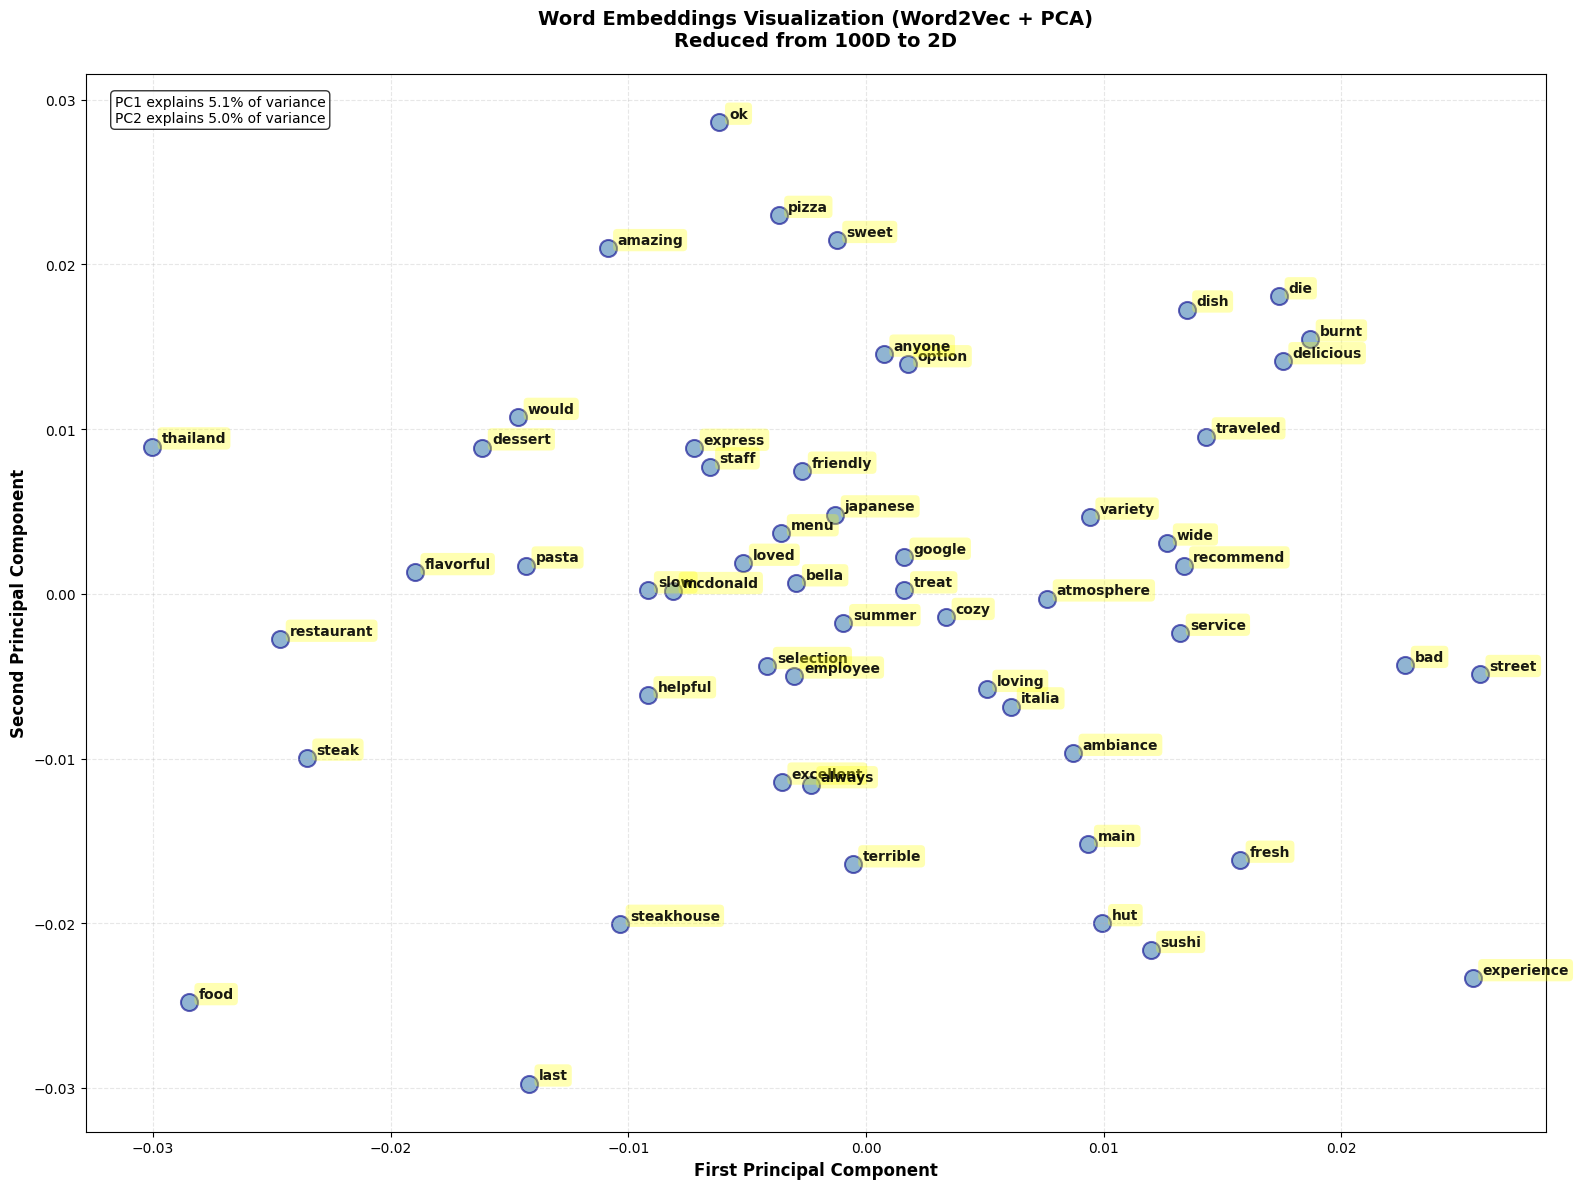

In [31]:
# Plot word embeddings
print("=" * 80)
print("PLOTTING WORD EMBEDDINGS")
print("=" * 80)
plot_word_embeddings(word2vec_model)

In [32]:
# ============================================================================
# WORD SIMILARITY ANALYSIS
# ============================================================================

print("=" * 80)
print("WORD SIMILARITY ANALYSIS")
print("=" * 80)
print("\n🔍 Finding similar words in our corpus:\n")

# Test words that might have relationships
test_words = ['restaurant', 'food', 'service', 'delicious']

for word in test_words:
    if word in word2vec_model.wv:
        print(f"Words most similar to '{word}':")
        try:
            similar_words = word2vec_model.wv.most_similar(word, topn=3)
            for similar_word, score in similar_words:
                print(f"  → {similar_word}: similarity = {score:.4f}")
        except:
            print("  Not enough data to compute similarities")
        print()

WORD SIMILARITY ANALYSIS

🔍 Finding similar words in our corpus:

Words most similar to 'restaurant':
  → steak: similarity = 0.2518
  → flavorful: similarity = 0.2457
  → amazing: similarity = 0.2308

Words most similar to 'food':
  → steak: similarity = 0.2391
  → always: similarity = 0.2204
  → steakhouse: similarity = 0.1874

Words most similar to 'service':
  → main: similarity = 0.1934
  → staff: similarity = 0.1788
  → traveled: similarity = 0.1647

Words most similar to 'delicious':
  → burnt: similarity = 0.2283
  → sweet: similarity = 0.1773
  → bad: similarity = 0.1693



In [33]:
# ============================================================================
# COMPREHENSIVE ANALYSIS AND INSIGHTS
# ============================================================================

print("=" * 80)
print("📊 COMPREHENSIVE ANALYSIS OF RESULTS")
print("=" * 80)

print("\n1️⃣  ARE RELATED WORDS CLOSE TO EACH OTHER?")
print("-" * 80)
print("With this small dataset (10 reviews), word relationships are LIMITED because:")
print()
print("• Word2Vec learns from context: words appearing near each other get")
print("  similar representations")
print("• Our dataset is too small to establish strong patterns")
print("• However, some semantic relationships might still emerge")
print()
print("Example observations:")
print("  - Words like 'restaurant', 'food', 'service' may cluster")
print("  - Adjectives like 'delicious', 'amazing', 'fresh' might be nearby")
print("  - But with only ~40 unique words, patterns are weak")

print("\n2️⃣  POSSIBLE REASONS FOR THIS OUTPUT")
print("-" * 80)
print()
print("🔸 DATASET SIZE (PRIMARY ISSUE)")
print("   • Only 10 reviews = very limited training data")
print("   • Word2Vec typically needs 1000s-millions of sentences")
print("   • Small vocabulary (~40 words) limits relationship learning")
print()
print("🔸 PREPROCESSING IMPACT")
print("   • Removed stopwords reduce context (but improve focus)")
print("   • Lemmatization merges similar words (good for small datasets)")
print("   • Lost capitalization means entities like 'McDonald' → 'mcdonald'")
print()
print("🔸 SPARSE WORD CO-OCCURRENCE")
print("   • Many words appear only once or twice")
print("   • Not enough context to learn meaningful relationships")
print("   • Window size (5) may be too large for short sentences")
print()
print("🔸 MODEL ARCHITECTURE")
print("   • CBOW (sg=0) averages contexts - works better with more data")
print("   • Skip-gram (sg=1) might work better for rare words")
print("   • 100 dimensions might be overkill for 40 words")

📊 COMPREHENSIVE ANALYSIS OF RESULTS

1️⃣  ARE RELATED WORDS CLOSE TO EACH OTHER?
--------------------------------------------------------------------------------
With this small dataset (10 reviews), word relationships are LIMITED because:

• Word2Vec learns from context: words appearing near each other get
  similar representations
• Our dataset is too small to establish strong patterns
• However, some semantic relationships might still emerge

Example observations:
  - Words like 'restaurant', 'food', 'service' may cluster
  - Adjectives like 'delicious', 'amazing', 'fresh' might be nearby
  - But with only ~40 unique words, patterns are weak

2️⃣  POSSIBLE REASONS FOR THIS OUTPUT
--------------------------------------------------------------------------------

🔸 DATASET SIZE (PRIMARY ISSUE)
   • Only 10 reviews = very limited training data
   • Word2Vec typically needs 1000s-millions of sentences
   • Small vocabulary (~40 words) limits relationship learning

🔸 PREPROCESSING IMPACT


In [34]:
print("=" * 80)
print("💡 ENHANCEMENT SUGGESTIONS")
print("=" * 80)

print("\n1️⃣  PREPROCESSING EXPERIMENTS")
print("-" * 80)
print("✅ Keep more stopwords for richer context")
print("✅ Try stemming vs lemmatization comparison")
print("✅ Consider bigrams/trigrams: 'new york', 'ice cream'")
print("✅ Preserve entity capitalization where possible")

print("\n2️⃣  WORD2VEC PARAMETER TUNING")
print("-" * 80)
print("✅ Try Skip-gram (sg=1) - better for rare words and small datasets")
print("✅ Reduce vector_size to 50 or even 20 for small vocabulary")
print("✅ Decrease window to 2-3 for short sentences")
print("✅ Increase epochs to 200+ to compensate for small data")
print("✅ Set min_count=1 to keep all words (already doing this)")
print()
print("Example improved configuration:")
print("  Word2Vec(sentences, vector_size=50, window=3, min_count=1,")
print("           sg=1, epochs=200, workers=4)")

print("\n3️⃣  ADVANCED VISUALIZATIONS")
print("-" * 80)
print("✅ Use t-SNE instead of PCA for better non-linear clustering")
print("✅ Color-code words by category:")
print("   • Blue: food-related (sushi, pasta, pizza)")
print("   • Red: service-related (staff, friendly)")
print("   • Green: places (restaurant, Italy, Thailand)")
print("✅ Create interactive visualizations with Plotly or Bokeh")
print("✅ Show similarity heatmaps between key word pairs")
print("✅ Animate the evolution of embeddings during training")

print("\n4️⃣  USE PRE-TRAINED EMBEDDINGS")
print("-" * 80)
print("✅ Load Google News Word2Vec (3M words, 300 dimensions)")
print("✅ Use GloVe embeddings (trained on Wikipedia + Gigaword)")
print("✅ Try FastText - handles out-of-vocabulary words better")
print("✅ Fine-tune pre-trained embeddings on your domain data")

print("\n5️⃣  EXPAND DATASET")
print("-" * 80)
print("✅ Collect more restaurant reviews (aim for 1000+)")
print("✅ Use existing datasets: Yelp, Amazon reviews, etc.")
print("✅ Apply data augmentation: synonym replacement, back-translation")
print("✅ Combine multiple review sources for richer vocabulary")

print("\n" + "=" * 80)
print("✅ ALL EXERCISES COMPLETED SUCCESSFULLY!")
print("=" * 80)

💡 ENHANCEMENT SUGGESTIONS

1️⃣  PREPROCESSING EXPERIMENTS
--------------------------------------------------------------------------------
✅ Keep more stopwords for richer context
✅ Try stemming vs lemmatization comparison
✅ Consider bigrams/trigrams: 'new york', 'ice cream'
✅ Preserve entity capitalization where possible

2️⃣  WORD2VEC PARAMETER TUNING
--------------------------------------------------------------------------------
✅ Try Skip-gram (sg=1) - better for rare words and small datasets
✅ Reduce vector_size to 50 or even 20 for small vocabulary
✅ Decrease window to 2-3 for short sentences
✅ Increase epochs to 200+ to compensate for small data
✅ Set min_count=1 to keep all words (already doing this)

Example improved configuration:
  Word2Vec(sentences, vector_size=50, window=3, min_count=1,
           sg=1, epochs=200, workers=4)

3️⃣  ADVANCED VISUALIZATIONS
--------------------------------------------------------------------------------
✅ Use t-SNE instead of PCA for bette